Initial parameters:
[0.47945912 4.9003743  2.75460644 4.54566578 6.14488933 3.38346934
 3.14863273 0.45271062 1.68665186 3.14085438]

Initial cost:
-0.3928351551849732

Checking gradient at initial point:

PSR gradient:
[-9.16975591e-01 -1.01860647e+00 -1.06940378e+00  8.91087436e-01
  4.50403105e-03  3.91520751e+00 -2.75916891e+00 -4.44830324e+00
  3.59002424e+00  4.59777148e+00]

Numerical gradient:
[-9.16975591e-01 -1.01860648e+00 -1.06940377e+00  8.91087436e-01
  4.50403095e-03  3.91520751e+00 -2.75916891e+00 -4.44830324e+00
  3.59002424e+00  4.59777148e+00]

Difference:
[-9.56359436e-11  4.46425341e-10 -1.41472167e-10  4.50801618e-11
  9.36976607e-11 -7.46869233e-11  3.42399442e-10 -2.34363640e-11
  3.69167807e-10 -3.90068422e-10]


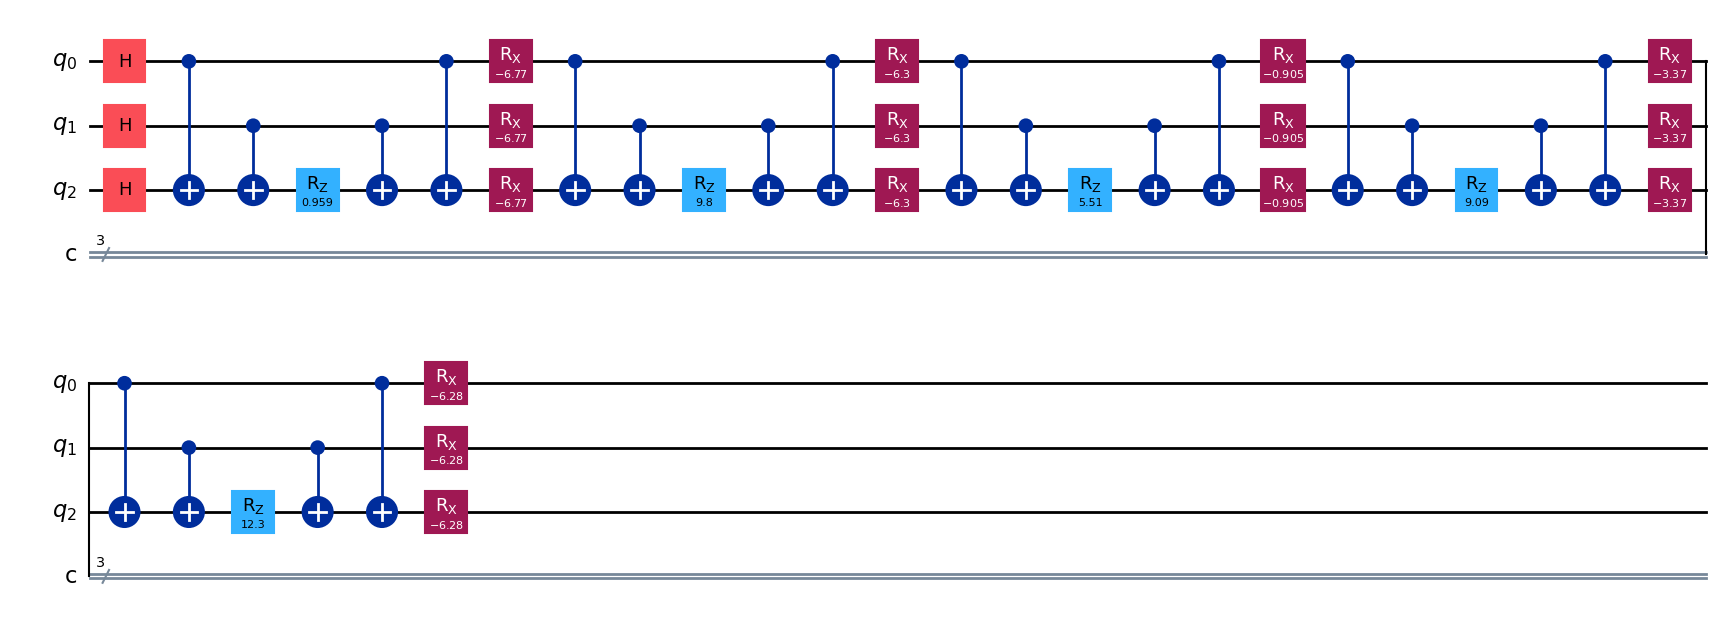

Epoch   0 | Cost = -0.39283516 | Grad norm = 8.97625346
Epoch  10 | Cost = -0.98954863 | Grad norm = 0.57935639
Epoch  20 | Cost = -0.99969500 | Grad norm = 0.09962880
Epoch  30 | Cost = -0.99999129 | Grad norm = 0.01685135
Epoch  40 | Cost = -0.99999975 | Grad norm = 0.00284445
Epoch  50 | Cost = -0.99999999 | Grad norm = 0.00047998
Epoch  60 | Cost = -1.00000000 | Grad norm = 0.00008099
Epoch  70 | Cost = -1.00000000 | Grad norm = 0.00001367
Epoch  80 | Cost = -1.00000000 | Grad norm = 0.00000231
Epoch  90 | Cost = -1.00000000 | Grad norm = 0.00000039
Epoch 100 | Cost = -1.00000000 | Grad norm = 0.00000007
Epoch 110 | Cost = -1.00000000 | Grad norm = 0.00000001
Epoch 120 | Cost = -1.00000000 | Grad norm = 0.00000000
Epoch 130 | Cost = -1.00000000 | Grad norm = 0.00000000
Epoch 140 | Cost = -1.00000000 | Grad norm = 0.00000000
Epoch 150 | Cost = -1.00000000 | Grad norm = 0.00000000
Epoch 160 | Cost = -1.00000000 | Grad norm = 0.00000000
Epoch 170 | Cost = -1.00000000 | Grad norm = 0.0

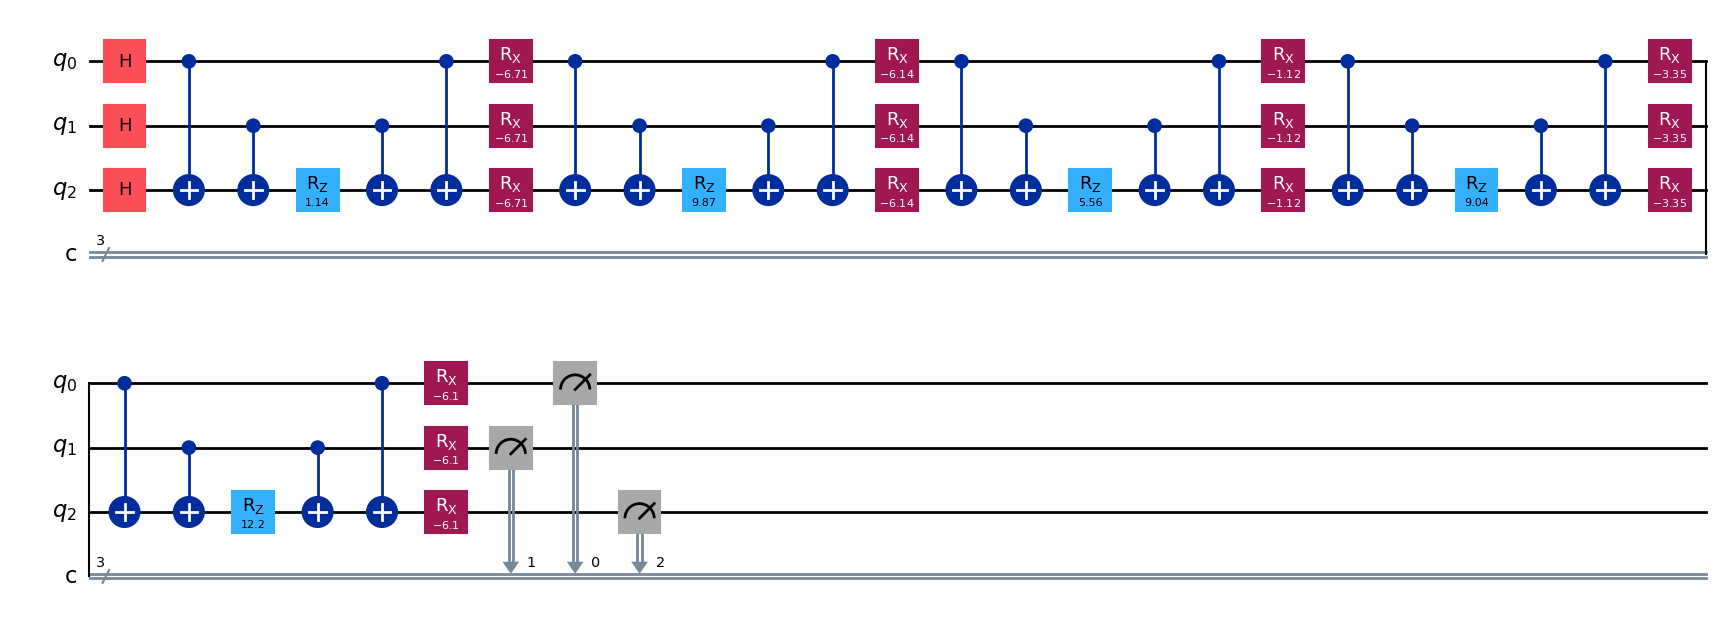


Measurement counts:
{'111': 497, '001': 547, '010': 532, '100': 472}


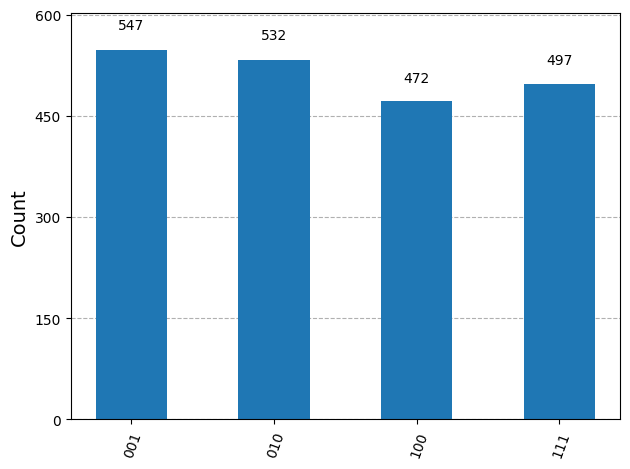

In [ ]:
from qiskit import QuantumRegister, QuantumCircuit, ClassicalRegister
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_histogram
from IPython.display import display
from numpy import pi
from qiskit_aer import AerSimulator
import numpy as np


# User choices
n = 3
p = 5
shots = 2048

epochs = 300
lr = 0.01


# Matrix construction for Hc = Z tensor Z tensor ... tensor Z
Z = np.array([[1, 0],
              [0, -1]], dtype=complex)

Hc = Z

for i in range(n - 1):
    Hc = np.kron(Hc, Z)


# Cost from statevector using inner product
# C = <psi|Hc|psi>
def cost_from_statevector(state):
    psi = state.data
    value = np.vdot(psi, Hc @ psi)

    return np.real(value)


# Cost layer: exp(-i gamma Z0 Z1 ... Zn-1)
def apply_cost_layer(qc, gamma):
    # Compute parity onto last qubit
    for q in range(n - 1):
        qc.cx(q, n - 1)

    # Rz(2 gamma) = exp(-i gamma Z)
    qc.rz(2 * gamma, n - 1)

    # Uncompute parity
    for q in reversed(range(n - 1)):
        qc.cx(q, n - 1)


# Mixer layer normally
# Hm = - sum_i Xi
# exp(-i beta Hm) = exp(+i beta sum_i Xi)
# exp(+i beta X) = Rx(-2 beta)

def apply_mixer_layer(qc, beta):
    for q in range(n):
        qc.rx(-2 * beta, q)


# Mixer layer with one qubit shifted
#
# layer_to_shift = which beta layer is being differentiated
# qubit_to_shift = which Rx inside that layer is shifted
# shifted_beta = beta + pi/4 or beta - pi/4

def apply_mixer_layer_with_one_qubit_shifted(qc, beta, qubit_to_shift, shifted_beta):
    for q in range(n):
        if q == qubit_to_shift:
            qc.rx(-2 * shifted_beta, q)
        else:
            qc.rx(-2 * beta, q)


# Build ordinary QAOA circuit
# params = [gamma_1,...,gamma_p,beta_1,...,beta_p]

def build_qaoa_circuit(params, measure=False):
    gammas = params[:p]
    betas = params[p:]

    qr = QuantumRegister(n, "q")
    cr = ClassicalRegister(n, "c")
    qc = QuantumCircuit(qr, cr)

    # Initial state = ground state of Hm = -sum Xi
    qc.h(qr)

    for k in range(p):
        apply_cost_layer(qc, gammas[k])
        apply_mixer_layer(qc, betas[k])

    if measure:
        qc.measure(qr, cr)

    return qc


# Build QAOA circuit where one mixer Rx gate is shifted

def build_qaoa_circuit_one_mixer_gate_shifted(params, layer_to_shift, qubit_to_shift, shifted_beta):
    gammas = params[:p]
    betas = params[p:]

    qr = QuantumRegister(n, "q")
    qc = QuantumCircuit(qr)

    qc.h(qr)

    for k in range(p):
        apply_cost_layer(qc, gammas[k])

        if k == layer_to_shift:
            apply_mixer_layer_with_one_qubit_shifted(
                qc,
                beta=betas[k],
                qubit_to_shift=qubit_to_shift,
                shifted_beta=shifted_beta
            )
        else:
            apply_mixer_layer(qc, betas[k])

    return qc


# Ordinary cost function

def cost_function(params):
    qc = build_qaoa_circuit(params, measure=False)
    state = Statevector.from_instruction(qc)

    return cost_from_statevector(state)


# Cost with one mixer Rx gate shifted

def cost_with_one_mixer_gate_shifted(params, layer_to_shift, qubit_to_shift, shifted_beta):
    qc = build_qaoa_circuit_one_mixer_gate_shifted(
        params,
        layer_to_shift,
        qubit_to_shift,
        shifted_beta
    )

    state = Statevector.from_instruction(qc)

    return cost_from_statevector(state)


# Correct PSR gradient

def gradient_psr(params):
    grad = np.zeros_like(params)
    shift = pi / 4

    
    # Gamma gradients
    
    # Each gamma appears in one effective cost gate.
    for i in range(p):
        plus = params.copy()
        minus = params.copy()

        plus[i] += shift
        minus[i] -= shift

        grad[i] = cost_function(plus) - cost_function(minus)

   
    # Beta gradients
    
    # Each beta appears in n different Rx gates.
    # So shift one Rx gate at a time and sum.

    for i in range(p, 2 * p):
        layer = i - p
        beta = params[i]

        total = 0.0

        for q in range(n):
            plus_cost = cost_with_one_mixer_gate_shifted(
                params,
                layer_to_shift=layer,
                qubit_to_shift=q,
                shifted_beta=beta + shift
            )

            minus_cost = cost_with_one_mixer_gate_shifted(
                params,
                layer_to_shift=layer,
                qubit_to_shift=q,
                shifted_beta=beta - shift
            )

            total += plus_cost - minus_cost

        grad[i] = total

    return grad


# Numerical finite-difference gradient for checking

def gradient_numerical(params, eps=1e-6):
    grad = np.zeros_like(params)

    for i in range(len(params)):
        plus = params.copy()
        minus = params.copy()

        plus[i] += eps
        minus[i] -= eps

        grad[i] = (cost_function(plus) - cost_function(minus)) / (2 * eps)

    return grad


# Initialize parameters

np.random.seed(7)
params = np.random.uniform(0, 2 * pi, 2 * p)

print("Initial parameters:")
print(params)

print("\nInitial cost:")
print(cost_function(params))


# Check PSR gradient vs numerical gradient

print("\nChecking gradient at initial point:")

g_psr = gradient_psr(params)
g_num = gradient_numerical(params)

print("\nPSR gradient:")
print(g_psr)

print("\nNumerical gradient:")
print(g_num)

print("\nDifference:")
print(g_psr - g_num)


# Show initial circuit
initial_qc = build_qaoa_circuit(params, measure=False)
display(initial_qc.draw(output="mpl"))


# Gradient descent using corrected PSR
cost_history = []

for epoch in range(epochs):
    cost = cost_function(params)
    cost_history.append(cost)

    grad = gradient_psr(params)

    params = params - lr * grad

    if epoch % 10 == 0:
        print(
            f"Epoch {epoch:3d} | "
            f"Cost = {cost:.8f} | "
            f"Grad norm = {np.linalg.norm(grad):.8f}"
        )


print("\nFinal parameters:")
print(params)

print("\nFinal cost:")
print(cost_function(params))


# Final circuit with measurement
final_qc = build_qaoa_circuit(params, measure=True)
display(final_qc.draw(output="mpl"))


# Measurement simulation
sim = AerSimulator()
result = sim.run(final_qc, shots=shots).result()
counts = result.get_counts()

print("\nMeasurement counts:")
print(counts)

display(plot_histogram(counts))